In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# 1. Introducción del database

El database se trata de un conmjunto de datos MNIST de una base de datos 
El database consiste en 27455 imágenes de Lengua de Señas Americano (ASL), cada imágen es de 28 x 28 pixeles en un formato de escalas de grises. Las imágenes pertenecen presentan una etiqueta que representa de 0-25 letras del abecedario en inglés (excluyendo la J = 9 y 25 = Z debido a que involucran movimientos). Viene separado en training data(27,455 casos) y el test data(7,172 casos), los cuales son aproximadamente la mitade de tamaño del standar de MNIST, pero con las etiquetas de label, pixel1, pixel2, ..., pixel784.

La variable objetivo es una etiqueta numérica que representa la clase de la letra correspondiente en el alfabeto dactilológico.

In [4]:
df = pd.read_csv('sign_mnist_train.csv')
labels = pd.read_csv('sign_mnist_test.csv')

# 2. Preprocesamiento de datos

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Normalizamos los valores de pixeles para agilizar el proceso de machine learning

In [6]:
columnas = [f'pixel{i}' for i in range(1, 785)]
df[columnas] = df[columnas].astype(float) / 255

Identificamos si hay un misbalance en las clases dentro del dataset

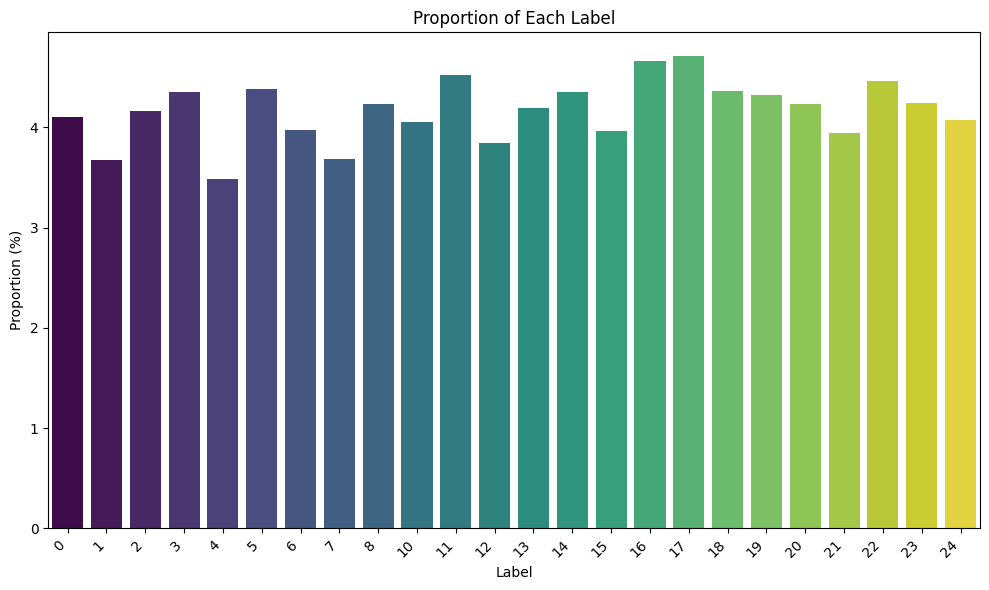

In [6]:
labels_counts = df['label'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=labels_counts.index, y=labels_counts.values, hue=labels_counts.index, palette='viridis', legend=False)
plt.title('Proportion of Each Label')
plt.xlabel('Label')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
print("Original class dsitribution:")
Counter(df['label'])

Original class dsitribution:


Counter({17: 1294,
         16: 1279,
         11: 1241,
         22: 1225,
         5: 1204,
         18: 1199,
         3: 1196,
         14: 1196,
         19: 1186,
         23: 1164,
         8: 1162,
         20: 1161,
         13: 1151,
         2: 1144,
         0: 1126,
         24: 1118,
         10: 1114,
         6: 1090,
         15: 1088,
         21: 1082,
         12: 1055,
         7: 1013,
         1: 1010,
         4: 957})

Normalizamos de igual forma el X_test con el mismo scaler 

In [7]:
X = df.drop('label', axis = 1)
Y = df['label']
X_test = labels.drop('label', axis = 1)/255
Y_test = labels['label']

Hacemos oversampling dentro de nuestro dataset de training

In [8]:
ros = RandomOverSampler(random_state=42)
X_balanced, Y_balanced = ros.fit_resample(X, Y)

Visualizamos imágenes aleatorias del dataset con los datos balanceados

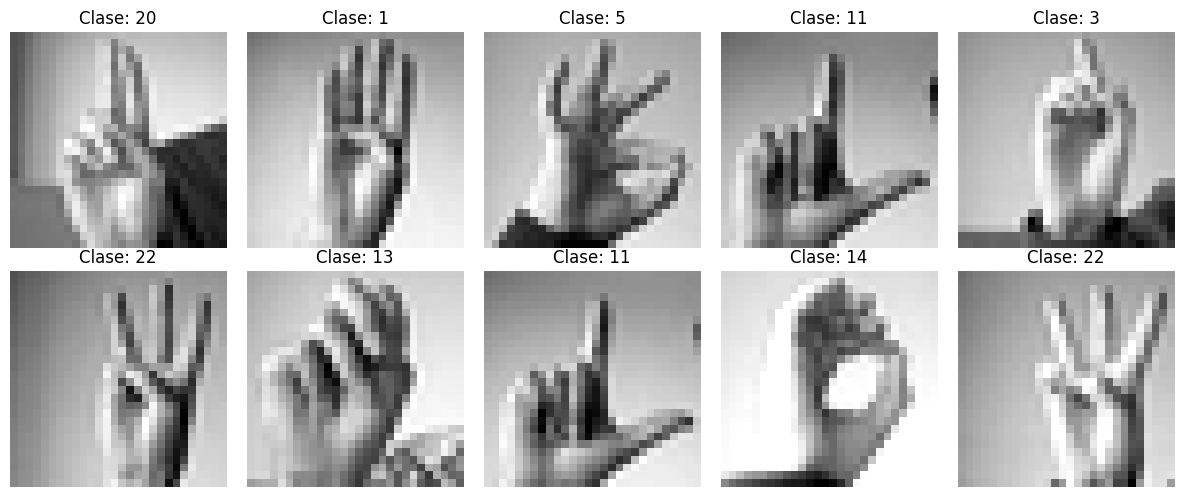

In [10]:
# Visualización de imágenes del dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    # Tomamos índices aleatorios de nuestros datos balanceados
    idx = np.random.randint(0, len(X_balanced))
    
    # Redimensionamos los 784 píxeles a una imagen 2D de 28x28
    img = X_balanced.iloc[idx].values.reshape(28, 28)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Clase: {Y_balanced.iloc[idx]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
Counter(Y_balanced)

Counter({3: 1294,
         6: 1294,
         2: 1294,
         13: 1294,
         16: 1294,
         8: 1294,
         22: 1294,
         18: 1294,
         10: 1294,
         20: 1294,
         17: 1294,
         19: 1294,
         21: 1294,
         23: 1294,
         24: 1294,
         1: 1294,
         12: 1294,
         11: 1294,
         15: 1294,
         4: 1294,
         0: 1294,
         5: 1294,
         7: 1294,
         14: 1294})

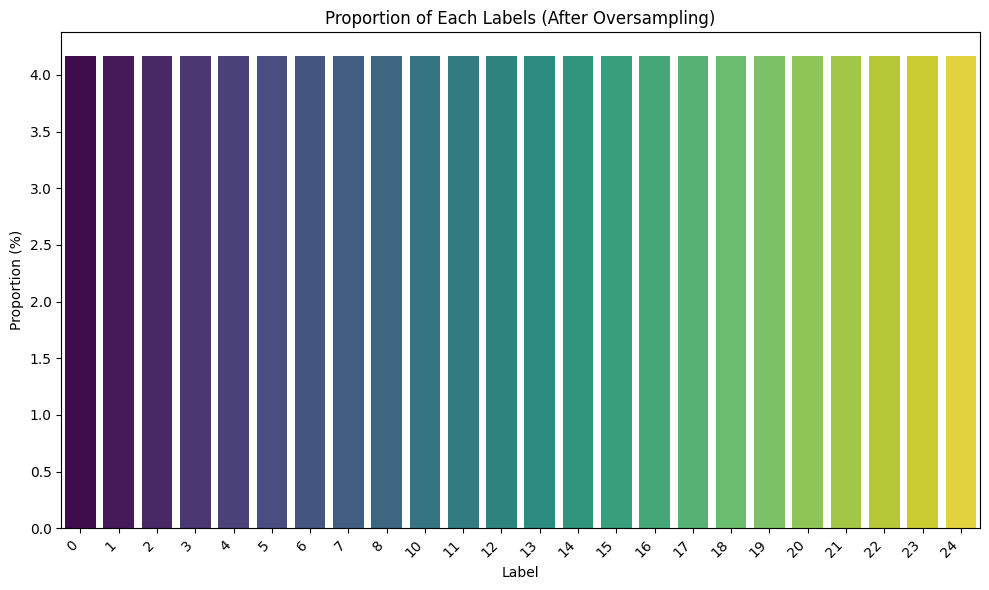

In [12]:
labels_counts_balanced = Y_balanced.value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=labels_counts_balanced.index, y=labels_counts_balanced.values, hue=labels_counts_balanced.index, palette='viridis', legend=False)
plt.title('Proportion of Each Labels (After Oversampling)')
plt.xlabel('Label')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
nulos_por_columna = df.isna().sum()
print(nulos_por_columna[nulos_por_columna > 0])

Series([], dtype: int64)


# 3. Definición del problema

* **Problema**: Clasificación Multiclase.
* **Justificación**: El objetivo es predecir una categoría discreta (una de las 24 letras posibles) a partir de un conjunto de variables de entrada (píxeles). No buscamos un valor continuo (regresión), sino identificar a qué "clase" pertenece la seña capturada.

# 4. Algoritmos de Clasificación y Optimización

Para resolver el problema de reconocimiento de lenguaje de señas (ASL), se seleccionaron dos algoritmos con naturalezas distintas: Random Forest (basado en ensambles de árboles) y Support Vector Machine (SVM) (basado en la búsqueda de hiperplanos de separación óptimos). Ambos fueron optimizados mediante RandomizedSearchCV, una técnica eficiente de búsqueda de hiperparámetros.

## Random Forest

In [9]:
# Visualizing accuracy vs. number of trees
n_estimators_range = range(10, 201, 10)
cv_scores = []

In [11]:
for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators = n, random_state = 42, n_jobs = -1)
    scores = cross_val_score(rf_temp, X_balanced, Y_balanced, cv = 5, scoring = 'accuracy')
    cv_scores.append(scores.mean())

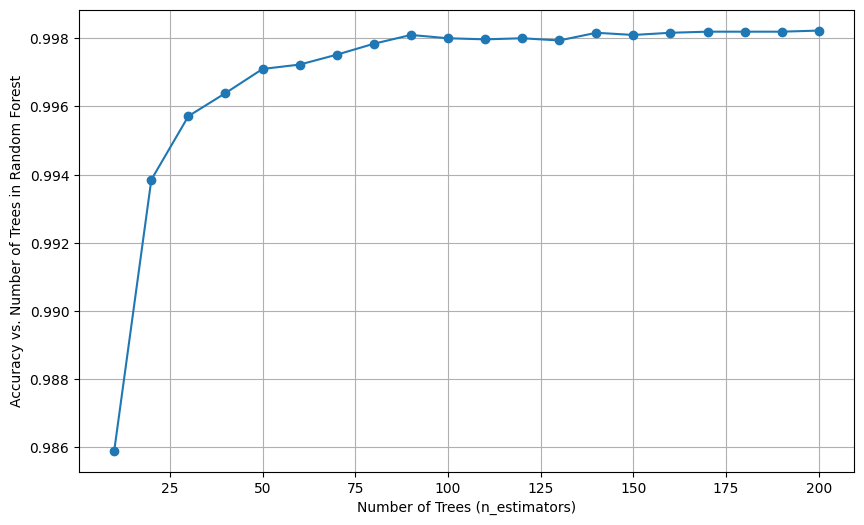

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, cv_scores, marker = 'o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy vs. Number of Trees in Random Forest")
plt.grid(True)
plt.show()

In [12]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,          # Solo 10 combinaciones aleatorias
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)
random_search.fit(X_balanced, Y_balanced)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [13]:
best_model = random_search.best_estimator_
print("Mejores Hiperparámetros: ", random_search.best_params_)

Mejores Hiperparámetros:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


De la optimización de parámetros conseguimos que el mejor modelo presenta:
* n_estimators = 100
* min_samples_split = 2
* min_samples_leaf = 1
* max_features = sqrt
* max_depth = None

n_estimators: Determina el número de árboles en el bosque. Al usar 100, permitimos que el modelo promedie suficientes predicciones para estabilizar el error.

max_features ('sqrt'): Controla cuántas variables (píxeles) se consideran al buscar la mejor división en cada nodo. Usar la raíz cuadrada ayuda a que los árboles sean menos correlacionados entre sí, mejorando la generalización.

max_depth (None): Permite que los árboles crezcan hasta que las hojas sean puras, capturando detalles intrincados de la forma de la mano.

In [14]:
y_pred = best_model.predict(X_test)

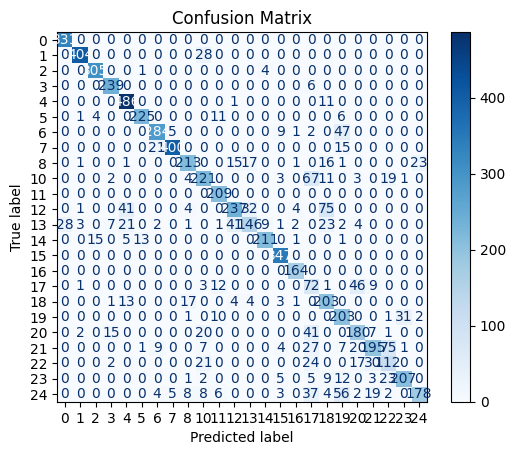

In [15]:
cm = confusion_matrix(Y_test, y_pred, labels = best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = best_model.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [16]:
report = classification_report(Y_test, y_pred, labels=best_model.classes_)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       331
           1       0.98      0.94      0.96       432
           2       0.94      0.98      0.96       310
           3       0.90      0.98      0.94       245
           4       0.86      0.98      0.91       498
           5       0.94      0.91      0.92       247
           6       0.89      0.82      0.85       348
           7       0.98      0.92      0.95       436
           8       0.86      0.74      0.79       288
          10       0.71      0.67      0.69       331
          11       0.84      1.00      0.91       209
          12       0.80      0.60      0.68       394
          13       0.73      0.50      0.60       291
          14       0.94      0.86      0.90       246
          15       0.93      1.00      0.96       347
          16       0.94      1.00      0.97       164
          17       0.26      0.50      0.34       144
    

Del Classification Report conseguimos un Accuracy del 80%, lo que implica que 4 de 5 imágenes son asignadas correctamente por el modelo. La gran mayoría de labels presentan valores del f1-score entre 0.9 y 1.0.

Las clases en las cuales se ha mostrado un desempeño bajo es en la 17 (letra R) y en la 22 (letra W) que presentan un f1-score de 0.34 y 0.51 respectivamente. De igual forma, en la Matriz de Confusión se observa que la clase 17 suele asignarse mucho a la clase 10 (letra K). Estos casos pueden surgir debido a que las señas de estas clases son similares. 

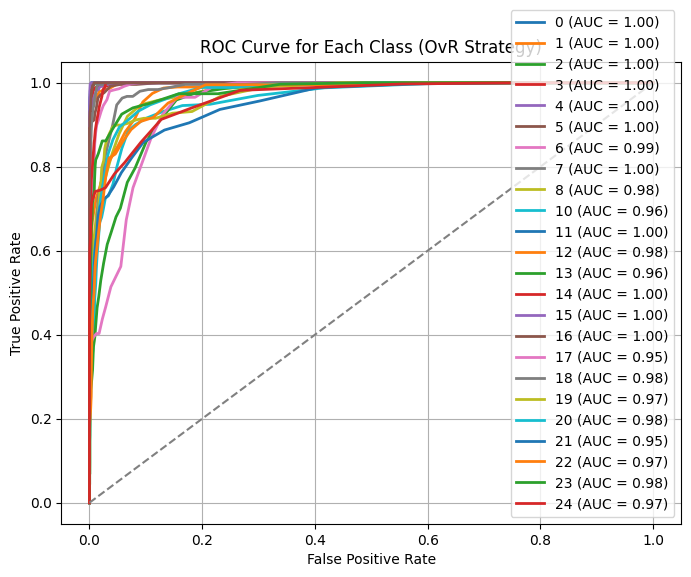

In [17]:
y_test_binarized = label_binarize(Y_test, classes=list(best_model.classes_))
y_score = best_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_label in enumerate(best_model.classes_):
    fpr[class_label], tpr[class_label], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[class_label] = auc(fpr[class_label], tpr[class_label])

plt.figure(figsize=(8, 6))
for class_label in best_model.classes_:
    plt.plot(fpr[class_label], tpr[class_label], lw=2,
             label=f'{class_label} (AUC = {roc_auc[class_label]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class (OvR Strategy)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## SVM

In [14]:
svm = SVC(probability  =True, random_state = 42)
param_grid_svm = {
    'C' : [1, 10, 100],
    'kernel' : ['rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [15]:
random_search_svm = RandomizedSearchCV(
    estimator = svm, 
    param_distributions = param_grid_svm, 
    n_iter=5, # Limita a 5 combinaciones para ahorrar tiempo
    cv = 3,   # 3 folds 
    scoring = 'accuracy', 
    n_jobs = -1, 
    verbose = 2,
    random_state=42
)
random_search_svm.fit(X_balanced, Y_balanced)
best_model_svm = random_search_svm.best_estimator_

print("Best Hyperparameters: ", random_search_svm.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Hyperparameters:  {'kernel': 'rbf', 'gamma': 'auto', 'C': 100}


De la optimización de parámetros conseguimos que el mejor modelo presenta:
* kernel = rbf
* gamma = auto
* C = 100

kernel ('rbf'): Es fundamental en procesamiento de imágenes, ya que permite crear fronteras de decisión no lineales, transformando los datos a un espacio donde las señas similares son separables.

C (100): Es el parámetro de regularización. Un valor alto como 100 indica que el modelo prioriza clasificar correctamente los puntos del set de entrenamiento, aceptando un margen más estrecho pero más preciso.

gamma ('auto'): Define la "influencia" de un solo ejemplo de entrenamiento. En modo 'auto', utiliza el inverso del número de características, ajustando la curvatura del límite de decisión.

In [19]:
y_pred_svm = best_model_svm.predict(X_test)

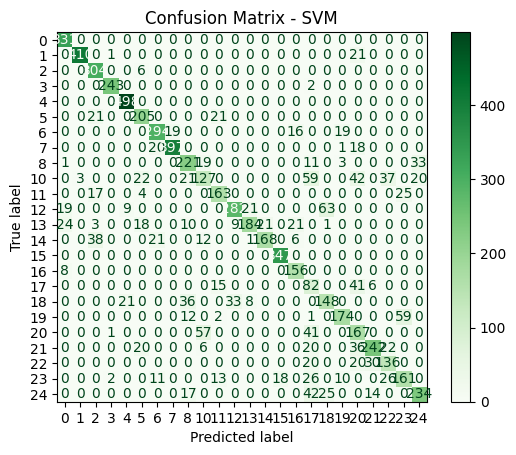

In [22]:
cm_svm = confusion_matrix(Y_test, y_pred_svm, labels = best_model_svm.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix = cm_svm, display_labels = best_model_svm.classes_)
disp_svm.plot(cmap = plt.cm.Greens)
plt.title("Confusion Matrix - SVM")
plt.show()

In [24]:
report_svm = classification_report(Y_test, y_pred_svm, labels = best_model_svm.classes_)
print("Classification Report: ")
print(report_svm)

Classification Report: 
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       331
           1       0.99      0.95      0.97       432
           2       0.79      0.98      0.88       310
           3       0.98      0.99      0.99       245
           4       0.94      1.00      0.97       498
           5       0.75      0.83      0.79       247
           6       0.85      0.84      0.85       348
           7       0.95      0.91      0.93       436
           8       0.70      0.77      0.73       288
          10       0.57      0.38      0.46       331
          11       0.76      0.78      0.77       209
          12       0.87      0.72      0.79       394
          13       0.86      0.63      0.73       291
          14       0.89      0.68      0.77       246
          15       0.95      1.00      0.97       347
          16       0.78      0.95      0.86       164
          17       0.27      0.57      0.37       144
   

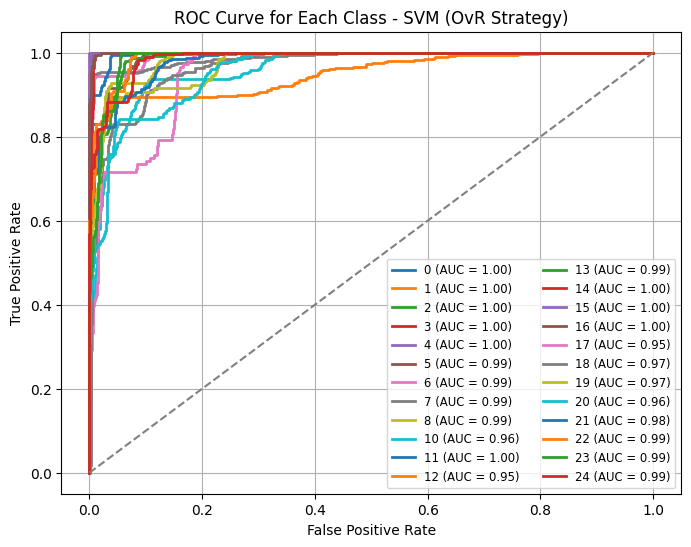

In [25]:
# Binarizar correctamente para OvR
y_test_binarized_svm = label_binarize(Y_test, classes=list(best_model_svm.classes_))
y_score_svm = best_model_svm.predict_proba(X_test)

fpr_svm = dict()
tpr_svm = dict()
roc_auc_svm = dict()

for i, class_label in enumerate(best_model_svm.classes_):
    fpr_svm[class_label], tpr_svm[class_label], _ = roc_curve(y_test_binarized_svm[:, i], y_score_svm[:, i])
    roc_auc_svm[class_label] = auc(fpr_svm[class_label], tpr_svm[class_label])

plt.figure(figsize=(8, 6))
for class_label in best_model_svm.classes_:
    plt.plot(fpr_svm[class_label], tpr_svm[class_label], lw=2,
             label=f'{class_label} (AUC = {roc_auc_svm[class_label]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class - SVM (OvR Strategy)')
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid(True)
plt.show()

# 5. Evaluación de desempeño

Métrica                  Random Forest            SVM

Accuracy (Exactitud)     80%                      79%

Macro F1-Score           0.79                     0.77

En ambos modelos, la diagonal principal es fuerte, lo que indica un buen desempeño general.

Random Forest mostró debilidad notable en la clase 17 (letra R), confundiéndola frecuentemente con la 10 (letra K). Esto ocurre porque visualmente ambas señas mantienen dedos extendidos hacia arriba en posiciones similares.

SVM tuvo un desempeño más balanceado pero sufrió una caída en la recuperación (recall) de las clases con texturas de píxeles muy parecidas, debido a que el escalado global de la imagen afecta la posición de los vectores de soporte.

# 6. Discusión Comparativa

Tras el análisis, el algoritmo que presentó un mejor desempeño fue Random Forest, aunque por un margen muy estrecho (80% vs 79% de Accuracy).

El dataset MNIST-ASL consiste en valores de píxeles crudos. Random Forest, al ser un algoritmo de particionamiento, es excelente identificando "píxeles clave" (umbrales de intensidad en áreas específicas de la imagen) que definen una letra, ignorando las áreas de fondo que no aportan información. Los árboles de decisión son menos sensibles a la falta de un escalado perfecto que el SVM. Aunque normalizamos los datos, las variaciones de iluminación en las fotos originales crean gradientes que el Random Forest maneja mejor mediante sus divisiones ortogonales.

Con 784 características, el SVM enfrenta el reto de la "maldición de la dimensionalidad". El kernel RBF intentó mapear estos datos, pero la complejidad del espacio resultante pudo causar que el modelo se volviera demasiado sensible a pequeñas variaciones, mientras que el ensamble de Random Forest proporcionó una generalización más estable.

Aunque ambos modelos son competentes, Random Forest es la opción preferida para este dataset específico debido a su eficiencia computacional (permite entrenar en fracciones del tiempo que toma SVM) y su capacidad para manejar la clasificación multiclase de forma nativa con un desempeño ligeramente superior en métricas de precisión y F1-score.